# Prototype Phase: TVAE for synthetic data generation
### create synthetic data and evaluate utility metric using TSTR and how well does the synthetic data captures relationship

In [2]:
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional, Union
from dataclasses import dataclass, field
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [3]:
RUN_LATENT_DIM_SWEEP = True  
FIXED_LATENT_DIM = 8         

In [4]:
@dataclass
class TVAEPreprocessorConfig:
    """Configuration for TVAE Preprocessor."""
    
    # Gaussian Mixture Model settings for continuous columns
    n_gmm_components: int = 10
    gmm_covariance_type: str = 'diag'
    gmm_max_iter: int = 100
    gmm_random_state: int = 42
    gmm_reg_covar: float = 1e-3
    
    # Categorical encoding settings
    categorical_encoding: str = 'one_hot'  # 'one_hot' or 'label'
    handle_unknown: str = 'ignore'  # 'ignore' or 'error'
    
    # Normalization settings
    normalize_continuous: bool = True
    eps: float = 1e-6  # Small epsilon for numerical stability
    
    # Column detection settings
    categorical_threshold: int = 20  # Max unique values to consider categorical
    
    def __post_init__(self):
        if self.categorical_encoding not in ['one_hot', 'label']:
            raise ValueError("categorical_encoding must be 'one_hot' or 'label'")
        if self.handle_unknown not in ['ignore', 'error']:
            raise ValueError("handle_unknown must be 'ignore' or 'error'")

## Column Info Storage

In [5]:
@dataclass
class ContinuousColumnInfo:
    """Stores information about a continuous column."""
    name: str
    gmm: GaussianMixture
    min_value: float
    max_value: float
    output_dim: int  # n_components (for mode) + 1 (for normalized value)

@dataclass
class CategoricalColumnInfo:
    """Stores information about a categorical column."""
    name: str
    categories: List[str]
    category_to_idx: Dict[str, int]
    output_dim: int  # Number of one-hot dimensions

## TVAE Preprocessor Class

In [6]:
class TVAEPreprocessor:
    """Preprocessor for Tabular VAE that handles mixed-type data.
    
    For continuous columns:
    - Fits a Gaussian Mixture Model (GMM)
    - Transforms to [mode_indicator (one-hot), normalized_value]
    
    For categorical columns:
    - One-hot encodes the categories
    """
    
    def __init__(self, config: Optional[TVAEPreprocessorConfig] = None):
        self.config = config or TVAEPreprocessorConfig()
        self.continuous_columns_info: List[ContinuousColumnInfo] = []
        self.categorical_columns_info: List[CategoricalColumnInfo] = []
        self.column_order: List[str] = []
        self.fitted = False
        
    def _detect_column_types(self, df: pd.DataFrame, 
                            continuous_columns: Optional[List[str]] = None,
                            categorical_columns: Optional[List[str]] = None
                           ) -> Tuple[List[str], List[str]]:
        """Detect or validate column types."""
        
        if continuous_columns is None and categorical_columns is None:
            # Auto-detect based on dtype and unique values
            continuous = []
            categorical = []
            
            for col in df.columns:
                if pd.api.types.is_numeric_dtype(df[col]):
                    n_unique = df[col].nunique()
                    if n_unique <= self.config.categorical_threshold:
                        categorical.append(col)
                    else:
                        continuous.append(col)
                else:
                    categorical.append(col)
                    
            return continuous, categorical
        
        elif continuous_columns is not None and categorical_columns is not None:
            # Validate provided columns
            all_cols = set(continuous_columns + categorical_columns)
            if all_cols != set(df.columns):
                raise ValueError("Provided columns don't match dataframe columns")
            return continuous_columns, categorical_columns
        
        else:
            raise ValueError("Either provide both column lists or neither")
    
    def fit(self, df: pd.DataFrame,
            continuous_columns: Optional[List[str]] = None,
            categorical_columns: Optional[List[str]] = None) -> 'TVAEPreprocessor':
        """Fit the preprocessor on the data.
        
        Args:
            df: Input dataframe
            continuous_columns: List of continuous column names (optional)
            categorical_columns: List of categorical column names (optional)
        """
        
        continuous_cols, categorical_cols = self._detect_column_types(
            df, continuous_columns, categorical_columns
        )
        
        self.column_order = list(df.columns)
        
        # Fit continuous columns with GMM
        for col in continuous_cols:
            data = df[col].values.reshape(-1, 1)
            
            # Fit Gaussian Mixture Model
            gmm = GaussianMixture(
                n_components=self.config.n_gmm_components,
                covariance_type=self.config.gmm_covariance_type,
                max_iter=self.config.gmm_max_iter,
                random_state=self.config.gmm_random_state,
                reg_covar=self.config.gmm_reg_covar
            )
            gmm.fit(data)
            
            info = ContinuousColumnInfo(
                name=col,
                gmm=gmm,
                min_value=float(data.min()),
                max_value=float(data.max()),
                output_dim=self.config.n_gmm_components + 1
            )
            self.continuous_columns_info.append(info)
        
        # Fit categorical columns
        for col in categorical_cols:
            categories = sorted(df[col].unique().astype(str).tolist())
            category_to_idx = {cat: idx for idx, cat in enumerate(categories)}
            
            info = CategoricalColumnInfo(
                name=col,
                categories=categories,
                category_to_idx=category_to_idx,
                output_dim=len(categories)
            )
            self.categorical_columns_info.append(info)
        
        self.fitted = True
        return self
    
    def _transform_continuous(self, data: np.ndarray, 
                             info: ContinuousColumnInfo) -> np.ndarray:
        """Transform a continuous column using its GMM.
        
        Returns: [mode_one_hot (n_components), normalized_value (1)]
        """
        data = data.reshape(-1, 1)
        n_samples = len(data)
        
        # Get GMM component assignments
        modes = info.gmm.predict(data)
        
        # One-hot encode the modes
        mode_one_hot = np.zeros((n_samples, self.config.n_gmm_components))
        mode_one_hot[np.arange(n_samples), modes] = 1.0
        
        # Normalize values to [0, 1] within each component
        normalized_values = np.zeros((n_samples, 1))
        
        for mode_idx in range(self.config.n_gmm_components):
            mask = modes == mode_idx
            if mask.sum() == 0:
                continue
                
            # Get mean and std of this component
            mean = info.gmm.means_[mode_idx, 0]
            std = np.sqrt(info.gmm.covariances_[mode_idx, 0])
            
            # Normalize: (x - mean) / (4 * std), then clip to [-0.99, 0.99]
            normalized = (data[mask, 0] - mean) / (4 * std + self.config.eps)
            normalized = np.clip(normalized, -0.99, 0.99)
            normalized_values[mask, 0] = normalized
        
        return np.concatenate([mode_one_hot, normalized_values], axis=1)
    
    def _transform_categorical(self, data: np.ndarray,
                              info: CategoricalColumnInfo) -> np.ndarray:
        """One-hot encode a categorical column."""
        n_samples = len(data)
        one_hot = np.zeros((n_samples, info.output_dim))
        
        for i, value in enumerate(data):
            value_str = str(value)
            if value_str in info.category_to_idx:
                idx = info.category_to_idx[value_str]
                one_hot[i, idx] = 1.0
            elif self.config.handle_unknown == 'error':
                raise ValueError(f"Unknown category '{value_str}' in column {info.name}")
            # else: handle_unknown == 'ignore', leave as all zeros
        
        return one_hot
    
    def transform(self, df: pd.DataFrame) -> np.ndarray:
        """Transform the data.
        
        Returns: Transformed array of shape (n_samples, total_output_dim)
        """
        if not self.fitted:
            raise RuntimeError("Preprocessor must be fitted before transform")
        
        # Reorder columns to match training order
        df = df[self.column_order]
        
        transformed_parts = []
        
        # Transform continuous columns
        for info in self.continuous_columns_info:
            data = df[info.name].values
            transformed = self._transform_continuous(data, info)
            transformed_parts.append(transformed)
        
        # Transform categorical columns
        for info in self.categorical_columns_info:
            data = df[info.name].values
            transformed = self._transform_categorical(data, info)
            transformed_parts.append(transformed)
        
        return np.concatenate(transformed_parts, axis=1)
    
    def fit_transform(self, df: pd.DataFrame,
                     continuous_columns: Optional[List[str]] = None,
                     categorical_columns: Optional[List[str]] = None) -> np.ndarray:
        """Fit and transform in one step."""
        self.fit(df, continuous_columns, categorical_columns)
        return self.transform(df)
    
    def inverse_transform(self, transformed_data: np.ndarray) -> pd.DataFrame:
        """Inverse transform the data back to original space.
        
        Args:
            transformed_data: Transformed array from transform()
            
        Returns: DataFrame with original column names and types
        """
        if not self.fitted:
            raise RuntimeError("Preprocessor must be fitted before inverse_transform")
        
        n_samples = len(transformed_data)
        result = {}
        current_idx = 0
        
        # Inverse transform continuous columns
        for info in self.continuous_columns_info:
            # Extract mode one-hot and normalized value
            mode_one_hot = transformed_data[:, current_idx:current_idx + self.config.n_gmm_components]
            normalized_values = transformed_data[:, current_idx + self.config.n_gmm_components]
            current_idx += info.output_dim
            
            # Get the selected mode for each sample
            modes = np.argmax(mode_one_hot, axis=1)
            
            # Reconstruct values
            reconstructed = np.zeros(n_samples)
            for mode_idx in range(self.config.n_gmm_components):
                mask = modes == mode_idx
                if mask.sum() == 0:
                    continue
                
                mean = info.gmm.means_[mode_idx, 0]
                std = np.sqrt(info.gmm.covariances_[mode_idx, 0])
                
                # Inverse of normalization
                values = normalized_values[mask] * 4 * std + mean
                reconstructed[mask] = values
            
            # Clip to original range
            reconstructed = np.clip(reconstructed, info.min_value, info.max_value)
            result[info.name] = reconstructed
        
        # Inverse transform categorical columns
        for info in self.categorical_columns_info:
            one_hot = transformed_data[:, current_idx:current_idx + info.output_dim]
            current_idx += info.output_dim
            
            # Get the category with highest probability
            category_indices = np.argmax(one_hot, axis=1)
            categories = [info.categories[idx] for idx in category_indices]
            result[info.name] = categories
        
        return pd.DataFrame(result)[self.column_order]
    
    def get_output_dim(self) -> int:
        """Get the total output dimension after transformation."""
        if not self.fitted:
            raise RuntimeError("Preprocessor must be fitted first")
        
        total = sum(info.output_dim for info in self.continuous_columns_info)
        total += sum(info.output_dim for info in self.categorical_columns_info)
        return total

    def get_output_info(self) -> List[Tuple[int, int, str]]:
        """Describe the layout of the transformed output for loss computation.
        
        Returns a list of (start_idx, dim, kind) segments, where kind is
        'discrete' for one-hot blocks (GMM mode indicators + categorical
        one-hot columns) that should use cross-entropy loss, and
        'continuous' for single normalized-value dims that should use MSE.
        """
        if not self.fitted:
            raise RuntimeError("Preprocessor must be fitted first")
        
        output_info = []
        idx = 0
        
        for info in self.continuous_columns_info:
            n_components = self.config.n_gmm_components
            output_info.append((idx, n_components, 'discrete'))       # mode one-hot
            output_info.append((idx + n_components, 1, 'continuous')) # normalized value
            idx += info.output_dim
        
        for info in self.categorical_columns_info:
            output_info.append((idx, info.output_dim, 'discrete'))    # category one-hot
            idx += info.output_dim
        
        return output_info
    
    def get_metadata(self) -> Dict:
        """Get metadata about the fitted preprocessor."""
        if not self.fitted:
            raise RuntimeError("Preprocessor must be fitted first")
        
        return {
            'continuous_columns': [info.name for info in self.continuous_columns_info],
            'categorical_columns': [info.name for info in self.categorical_columns_info],
            'output_dim': self.get_output_dim(),
            'continuous_dims': {info.name: info.output_dim for info in self.continuous_columns_info},
            'categorical_dims': {info.name: info.output_dim for info in self.categorical_columns_info}
        }

In [7]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the original regression dataset
housing = fetch_california_housing(as_frame=True)
data = housing.frame
real_data = data

In [8]:
cols = []
for _ in data:
    cols.append(_)

cols

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

In [9]:
# Let the preprocessor auto-detect column types
config = TVAEPreprocessorConfig(
    n_gmm_components=5
)

preprocessor = TVAEPreprocessor(config)

transformed = preprocessor.fit_transform(data, continuous_columns=cols, categorical_columns=[])

print("Auto-detected column types:")
print(preprocessor.get_metadata())

Auto-detected column types:
{'continuous_columns': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'], 'categorical_columns': [], 'output_dim': 54, 'continuous_dims': {'MedInc': 6, 'HouseAge': 6, 'AveRooms': 6, 'AveBedrms': 6, 'Population': 6, 'AveOccup': 6, 'Latitude': 6, 'Longitude': 6, 'MedHouseVal': 6}, 'categorical_dims': {}}


In [10]:
# View metadata
metadata = preprocessor.get_metadata()
print("\nPreprocessor metadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")


Preprocessor metadata:
  continuous_columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
  categorical_columns: []
  output_dim: 54
  continuous_dims: {'MedInc': 6, 'HouseAge': 6, 'AveRooms': 6, 'AveBedrms': 6, 'Population': 6, 'AveOccup': 6, 'Latitude': 6, 'Longitude': 6, 'MedHouseVal': 6}
  categorical_dims: {}


In [11]:
# Inverse transform
reconstructed = preprocessor.inverse_transform(transformed)

print("\nReconstructed data:")
print(reconstructed.head())

# Check reconstruction error for continuous columns
for col in cols:
    mae = np.abs(data[col] - reconstructed[col]).mean()
    print(f"\nMAE for {col}: {mae:.4f}")


Reconstructed data:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971881      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288135   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

MAE for MedInc: 0.0000

MAE for HouseAge: 0.0000

MAE for AveRooms: 0.0002

MAE for AveBedrms: 0.0000

MAE for Population: 0.0000

MAE for AveOccup: 0.0036

MAE for Latitude: 0.0000

MAE for Longitude: 0.0005

MAE for MedHouseVal: 0.0000


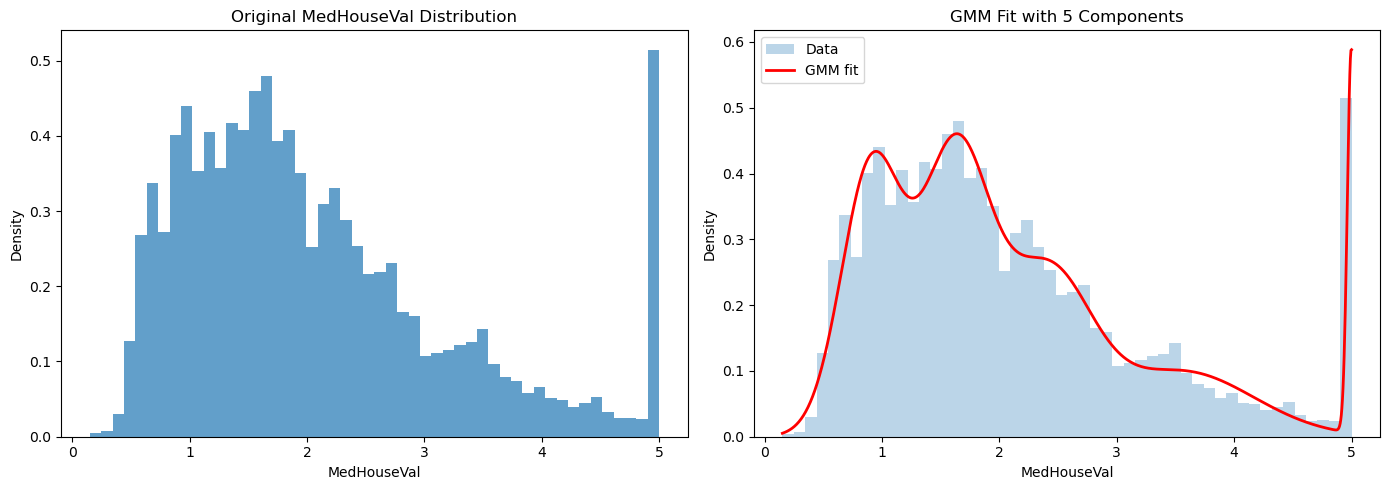

In [12]:
import matplotlib.pyplot as plt

# Visualize GMM fit for a continuous column

col_name = 'MedHouseVal'

col_info = next(info for info in preprocessor.continuous_columns_info if info.name == col_name)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(data[col_name], bins=50, alpha=0.7, density=True)
axes[0].set_title(f'Original {col_name} Distribution')
axes[0].set_xlabel(col_name)
axes[0].set_ylabel('Density')

# GMM components
x_range = np.linspace(data[col_name].min(), data[col_name].max(), 1000).reshape(-1, 1)
log_prob = col_info.gmm.score_samples(x_range)
axes[1].hist(data[col_name], bins=50, alpha=0.3, density=True, label='Data')
axes[1].plot(x_range, np.exp(log_prob), 'r-', linewidth=2, label='GMM fit')
axes[1].set_title(f'GMM Fit with {config.n_gmm_components} Components')
axes[1].set_xlabel(col_name)
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# TVAE Implementation

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from dataclasses import dataclass
import numpy as np
from typing import Optional, Tuple, List
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## TVAE Configuration

In [14]:
@dataclass
class TVAEConfig:
    """Configuration for TVAE model."""
    
    # Architecture
    input_dim: int  # Set by preprocessor output dimension
    latent_dim: int = 10
    encoder_hidden_dims: List[int] = None
    decoder_hidden_dims: List[int] = None
    output_info: List[Tuple[int, int, str]] = None
    
    # Training
    batch_size: int = 32
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    num_epochs: int = 300
    
    # Loss weighting
    beta: float = 1.0  # Weight for KL divergence term
    beta_start: float = 0.0        # KL weight at epoch 0 (warm-up start)
    beta_warmup_epochs: int = 20   # epochs to linearly ramp beta_start -> beta
    use_beta_warmup: bool = False   # if False, beta is fixed at `beta` for all epochs
    
    # Regularization
    dropout_rate: float = 0.2
    use_batch_norm: bool = True
    
    # Device
    device: str = 'cpu'
    
    def __post_init__(self):
        if self.encoder_hidden_dims is None:
            self.encoder_hidden_dims = [self.input_dim * 2, self.input_dim]
        if self.decoder_hidden_dims is None:
            self.decoder_hidden_dims = [self.input_dim, self.input_dim * 2]
            
        if self.beta_start < 0:
            raise ValueError("beta_start must be non-negative")
        if self.beta_warmup_epochs < 0:
            raise ValueError("beta_warmup_epochs must be non-negative")
        
        if self.latent_dim <= 0:
            raise ValueError("latent_dim must be positive")
        if self.batch_size <= 0:
            raise ValueError("batch_size must be positive")
        if self.learning_rate <= 0:
            raise ValueError("learning_rate must be positive")
        if self.beta <= 0:
            raise ValueError("beta must be positive")
        if not 0 <= self.dropout_rate < 1:
            raise ValueError("dropout_rate must be in [0, 1)")

## Encoder Network

In [15]:
class Encoder(nn.Module):
    """Encoder network that maps input to latent distribution parameters."""
    
    def __init__(self, input_dim: int, latent_dim: int, 
                 hidden_dims: List[int], dropout_rate: float = 0.2,
                 use_batch_norm: bool = True):
        super().__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.use_batch_norm = use_batch_norm
        
        # Build hidden layers
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            layers.append(nn.ReLU())
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            
            prev_dim = hidden_dim
        
        self.hidden_layers = nn.Sequential(*layers)
        
        # Latent space: mu and log_var
        self.mu_layer = nn.Linear(prev_dim, latent_dim)
        self.logvar_layer = nn.Linear(prev_dim, latent_dim)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Forward pass returns mu and log_var of the latent distribution.
        
        Args:
            x: Input tensor of shape (batch_size, input_dim)
            
        Returns:
            mu: Mean of latent distribution (batch_size, latent_dim)
            logvar: Log variance of latent distribution (batch_size, latent_dim)
        """
        h = self.hidden_layers(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

## Decoder Network

In [16]:
class Decoder(nn.Module):
    """Decoder network that reconstructs input from latent representation."""
    
    def __init__(self, latent_dim: int, output_dim: int,
                 hidden_dims: List[int], dropout_rate: float = 0.2,
                 use_batch_norm: bool = True):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.output_dim = output_dim
        self.use_batch_norm = use_batch_norm
        
        # Build hidden layers
        layers = []
        prev_dim = latent_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            layers.append(nn.ReLU())
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            
            prev_dim = hidden_dim
        
        self.hidden_layers = nn.Sequential(*layers)
        
        # Output layer: reconstruct input
        self.output_layer = nn.Linear(prev_dim, output_dim)
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """Forward pass reconstructs input from latent representation.
        
        Args:
            z: Latent representation (batch_size, latent_dim)
            
        Returns:
            Reconstructed data (batch_size, output_dim)
        """
        h = self.hidden_layers(z)
        x_recon = self.output_layer(h)
        return x_recon

## TVAE Model

In [17]:
class TVAE(nn.Module):
    """Tabular Variational Autoencoder for mixed-type data."""
    
    def __init__(self, config: TVAEConfig):
        super().__init__()
        self.config = config
        
        # Build encoder and decoder
        self.encoder = Encoder(
            input_dim=config.input_dim,
            latent_dim=config.latent_dim,
            hidden_dims=config.encoder_hidden_dims,
            dropout_rate=config.dropout_rate,
            use_batch_norm=config.use_batch_norm
        )
        
        self.decoder = Decoder(
            latent_dim=config.latent_dim,
            output_dim=config.input_dim,
            hidden_dims=config.decoder_hidden_dims,
            dropout_rate=config.dropout_rate,
            use_batch_norm=config.use_batch_norm
        )

        self.sigma = nn.Parameter(torch.ones(config.input_dim) * 0.1)
        
        # Reconstruction loss
        self.output_info = config.output_info or [(0, config.input_dim, 'continuous')]
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.kl_losses = []
        self.recon_losses = []
    
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Encode input to latent distribution parameters."""
        return self.encoder(x)
    
    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """Reparameterization trick for sampling from latent distribution."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode from latent representation to reconstructed input."""
        return self.decoder(z)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Full forward pass: encode, sample, decode.
        
        Args:
            x: Input data (batch_size, input_dim)
            
        Returns:
            x_recon: Reconstructed data
            mu: Mean of latent distribution
            logvar: Log variance of latent distribution
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar
    
    def compute_loss(self, x: torch.Tensor, x_recon: torch.Tensor,
                     mu: torch.Tensor, logvar: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Compute VAE loss: reconstruction + KL divergence.
        
        Args:
            x: Input data
            x_recon: Reconstructed data
            mu: Mean of latent distribution
            logvar: Log variance of latent distribution
            
        Returns:
            total_loss: Sum of reconstruction and KL losses
            recon_loss: Reconstruction loss (MSE)
            kl_loss: KL divergence loss
        """
        # Reconstruction loss: Cross Entropy
        batch_size = x.shape[0]
        recon_loss = 0.0

        for start, dim, kind in self.output_info:
            end = start + dim
            if kind == 'continuous':
                std = self.sigma[start:end]
                recon = torch.tanh(x_recon[:, start:end])
                nll = ((x[:, start:end] - recon) ** 2) / (2 * std ** 2) + torch.log(std)
                recon_loss = recon_loss + nll.sum()
            else:  # discrete: one-hot mode indicator or categorical block
                target = torch.argmax(x[:, start:end], dim=1)
                recon_loss = recon_loss + nn.functional.cross_entropy(
                    x_recon[:, start:end], target, reduction='sum'
                )

        recon_loss = recon_loss / batch_size

        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        kl_loss = kl_loss / batch_size
        
        # Total loss
        total_loss = recon_loss + self.config.beta * kl_loss
        
        return total_loss, recon_loss, kl_loss
    
    def to_device(self, device: str):
        """Move model to specified device."""
        self.to(device)
        self.config.device = device

## TVAE Trainer

In [18]:
class TVAETrainer:
    """Trainer for TVAE model."""
    
    def __init__(self, model: TVAE, config: TVAEConfig):
        self.model = model
        self.config = config
        
        
        # Optimizer
        self.optimizer = optim.Adam(
            model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        # Move model to device
        self.model.to(config.device)

        self.best_prior_mismatch = float('inf')
        self.best_state_dict = None
    
    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float, float]:
        """Train for one epoch.
        
        Returns:
            avg_total_loss, avg_recon_loss, avg_kl_loss
        """
        self.model.train()
        
        total_loss = 0.0
        recon_loss_sum = 0.0
        kl_loss_sum = 0.0
        num_batches = 0
        
        for batch_x in train_loader:
            batch_x = batch_x[0].to(self.config.device)
            
            # Forward pass
            x_recon, mu, logvar = self.model(batch_x)
            
            # Compute loss
            loss, recon_loss, kl_loss = self.model.compute_loss(batch_x, x_recon, mu, logvar)
            
            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            with torch.no_grad():
                self.model.sigma.clamp_(0.01, 1.0)
            
            
            # Track losses
            total_loss += loss.item()
            recon_loss_sum += recon_loss.item()
            kl_loss_sum += kl_loss.item()
            num_batches += 1
        
        return (total_loss / num_batches, 
                recon_loss_sum / num_batches, 
                kl_loss_sum / num_batches)
    
    @torch.no_grad()
    def validate(self, val_loader: DataLoader) -> Tuple[float, float, float]:
        """Validate the model.
        
        Returns:
            avg_total_loss, avg_recon_loss, avg_kl_loss
        """
        self.model.eval()
        
        total_loss = 0.0
        recon_loss_sum = 0.0
        kl_loss_sum = 0.0
        num_batches = 0
        
        for batch_x in val_loader:
            batch_x = batch_x[0].to(self.config.device)
            
            # Forward pass
            x_recon, mu, logvar = self.model(batch_x)
            
            # Compute loss
            loss, recon_loss, kl_loss = self.model.compute_loss(batch_x, x_recon, mu, logvar)
            
            # Track losses
            total_loss += loss.item()
            recon_loss_sum += recon_loss.item()
            kl_loss_sum += kl_loss.item()
            num_batches += 1
        
        return (total_loss / num_batches, 
                recon_loss_sum / num_batches, 
                kl_loss_sum / num_batches)
    
    def fit(self, train_loader: DataLoader, val_loader: Optional[DataLoader] = None) -> dict:
        """Fit the model.
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader (optional)
            
        Returns:
            Dictionary with training history
        """
        history = {
            'train_loss': [],
            'train_recon_loss': [],
            'train_kl_loss': [],
            'val_loss': [],
            'val_recon_loss': [],
            'val_kl_loss': [],
            'beta': []
        }
        
        for epoch in range(self.config.num_epochs):
            # Linear KL warm-up: ramp beta from beta_start up to the target beta
            if self.config.beta_warmup_epochs > 0 and self.config.use_beta_warmup:
                warmup_frac = min(1.0, (epoch + 1) / self.config.beta_warmup_epochs)
                current_beta = self.config.beta_start + warmup_frac * (self.config.beta - self.config.beta_start)
            else:
                current_beta = self.config.beta
            self.model.config.beta = current_beta   # compute_loss reads this at loss time
            history['beta'].append(current_beta)
            # Train
            train_loss, train_recon, train_kl = self.train_epoch(train_loader)
            history['train_loss'].append(train_loss)
            history['train_recon_loss'].append(train_recon)
            history['train_kl_loss'].append(train_kl)
            
            # Validate
            if val_loader is not None:
                val_loss, val_recon, val_kl = self.validate(val_loader)
                # Track prior calibration over the full run, not just at sweep time.
                # Reconstruction/classification loss can keep improving even as the
                # encoded posterior drifts away from N(0,1), which is exactly what
                # breaks generation quality later -- so checkpoint on calibration,
                # not on val_loss alone.
                current_mismatch = prior_mismatch_score(self.model, val_loader.dataset[:][0].numpy(), self.config.device)
                history.setdefault('prior_mismatch', []).append(current_mismatch)

                if current_mismatch < self.best_prior_mismatch:
                    self.best_prior_mismatch = current_mismatch
                    self.best_state_dict = {k: v.clone() for k, v in self.model.state_dict().items()}
                history['val_loss'].append(val_loss)
                history['val_recon_loss'].append(val_recon)
                history['val_kl_loss'].append(val_kl)
                
                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch + 1}/{self.config.num_epochs} - "
                          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            else:
                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch + 1}/{self.config.num_epochs} - "
                          f"Train Loss: {train_loss:.4f}")

        if self.best_state_dict is not None:
            self.model.load_state_dict(self.best_state_dict)
            print(f"\nRestored best checkpoint (prior_mismatch={self.best_prior_mismatch:.4f})")
        
        return history

In [19]:
# Get preprocessor metadata
metadata = preprocessor.get_metadata()
input_dim = metadata['output_dim']
output_info = preprocessor.get_output_info()

print(f"Input dimension from preprocessor: {input_dim}")
print(f"Transformed data shape: {transformed.shape}")

Input dimension from preprocessor: 54
Transformed data shape: (20640, 54)


In [20]:
# output_info = preprocessor.get_output_info()
# # Create TVAE config
# tvae_config = TVAEConfig(
#     input_dim=input_dim,
#     latent_dim=8,
#     encoder_hidden_dims=[64, 32],
#     decoder_hidden_dims=[32, 64],
#     batch_size=64,
#     learning_rate=1e-2,
#     num_epochs=100,
#     beta=0.5,
#     dropout_rate=0.1,
#     use_batch_norm=True,
#     device='cpu',
#     output_info=output_info
# )

# # Initialize model
# tvae = TVAE(tvae_config)
# print(f"\nTVAE Model:")
# print(tvae)

In [21]:
# Create data loader
transformed_tensor = torch.FloatTensor(transformed)
dataset = TensorDataset(transformed_tensor)

# Split into train and validation (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64  # used for both the sweep and the final run

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Train samples: 16512
Val samples: 4128


In [22]:
@torch.no_grad()
def prior_mismatch_score(model, data, device):
    """Lower is better. Measures how far the aggregate encoded posterior
    (mu, logvar) is from matching the N(0,1) prior across the dataset —
    a large value means samples drawn from the prior at generation time
    will look nothing like what the decoder was actually trained on."""
    model.eval()
    mu, logvar = model.encode(torch.FloatTensor(data).to(device))
    mu = mu.cpu().numpy()
    std = np.exp(0.5 * logvar.cpu().numpy())
    mean_shift = np.abs(mu.mean(axis=0)).mean()       # want ~0
    std_dev_from_one = np.abs(mu.std(axis=0) - 1.0).mean()  # want ~0
    return mean_shift + std_dev_from_one



def train_tvae_model(latent_dim, num_epochs, beta, beta_start, beta_warmup_epochs,
                      input_dim, output_info, train_loader, val_loader,
                      encoder_hidden_dims=None, decoder_hidden_dims=None,
                      batch_size=64, learning_rate=1e-3, dropout_rate=0.1,
                      device='cpu', use_beta_warmup=False, verbose=False):
    """Build, train, and return a TVAE model + its final history."""
    cfg = TVAEConfig(
        input_dim=input_dim,
        latent_dim=latent_dim,
        encoder_hidden_dims=encoder_hidden_dims,
        decoder_hidden_dims=decoder_hidden_dims,
        batch_size=batch_size,
        learning_rate=learning_rate,
        num_epochs=num_epochs,
        beta=beta,
        beta_start=beta_start,
        beta_warmup_epochs=beta_warmup_epochs,
        use_beta_warmup=use_beta_warmup,
        dropout_rate=dropout_rate,
        use_batch_norm=True,
        device=device,
        output_info=output_info
    )
    model = TVAE(cfg)
    trainer = TVAETrainer(model, cfg)
    history = trainer.fit(train_loader, val_loader)
    if verbose:
        print(f"latent_dim={latent_dim} -> final val_loss={history['val_loss'][-1]:.4f}")
    return model, trainer, history

In [23]:
if RUN_LATENT_DIM_SWEEP:
    sweep_epochs = 30
    candidate_dims = [4, 8, 12, 16]
    sweep_results = []

    for ld in candidate_dims:
        model, _, hist = train_tvae_model(
            latent_dim=ld,
            num_epochs=sweep_epochs,
            beta=0.5, beta_start=0.0, beta_warmup_epochs=15,
            input_dim=input_dim, output_info=output_info,
            train_loader=train_loader, val_loader=val_loader,
            verbose=True
        )
        mismatch = prior_mismatch_score(model, transformed, tvae_config.device if 'tvae_config' in dir() else 'cpu')
        sweep_results.append({
            'latent_dim': ld,
            'final_val_loss': hist['val_loss'][-1],
            'prior_mismatch': mismatch
        })

    sweep_df = pd.DataFrame(sweep_results)
    print(sweep_df)

    # Tie-break on prior calibration, not just val_loss -- a model that fits well
    # but has badly miscalibrated latents will generate garbage despite a low ELBO
    best_latent_dim = sweep_df.loc[sweep_df['prior_mismatch'].idxmin(), 'latent_dim']
    print(f"\nBest latent_dim (by prior calibration): {best_latent_dim}")
else:
    best_latent_dim = FIXED_LATENT_DIM
    print(f"Skipping sweep, using fixed latent_dim={best_latent_dim}")

Epoch 10/30 - Train Loss: -3.3117 | Val Loss: -4.0411
Epoch 20/30 - Train Loss: -3.6572 | Val Loss: -4.4718
Epoch 30/30 - Train Loss: -3.8355 | Val Loss: -4.6489

Restored best checkpoint (prior_mismatch=0.0346)
latent_dim=4 -> final val_loss=-4.6489
Epoch 10/30 - Train Loss: -3.3351 | Val Loss: -4.1321
Epoch 20/30 - Train Loss: -3.7912 | Val Loss: -4.6822
Epoch 30/30 - Train Loss: -3.9895 | Val Loss: -5.0231

Restored best checkpoint (prior_mismatch=0.2926)
latent_dim=8 -> final val_loss=-5.0231
Epoch 10/30 - Train Loss: -3.1070 | Val Loss: -3.9503
Epoch 20/30 - Train Loss: -3.7716 | Val Loss: -4.8188
Epoch 30/30 - Train Loss: -4.0608 | Val Loss: -5.2276

Restored best checkpoint (prior_mismatch=0.3935)
latent_dim=12 -> final val_loss=-5.2276
Epoch 10/30 - Train Loss: -3.0259 | Val Loss: -3.8822
Epoch 20/30 - Train Loss: -3.8271 | Val Loss: -4.8828
Epoch 30/30 - Train Loss: -4.1132 | Val Loss: -5.2262

Restored best checkpoint (prior_mismatch=0.4530)
latent_dim=16 -> final val_loss=-5

In [24]:
tvae, trainer, history = train_tvae_model(
    latent_dim=int(best_latent_dim),
    num_epochs=100,
    beta=1.0, beta_start=1.0, beta_warmup_epochs=0, use_beta_warmup=False,
    input_dim=input_dim, output_info=output_info,
    train_loader=train_loader, val_loader=val_loader,
    verbose=True
)

Epoch 10/100 - Train Loss: -1.3856 | Val Loss: -1.7203
Epoch 20/100 - Train Loss: -1.5477 | Val Loss: -1.9177
Epoch 30/100 - Train Loss: -1.6274 | Val Loss: -2.0360
Epoch 40/100 - Train Loss: -1.6543 | Val Loss: -2.0681
Epoch 50/100 - Train Loss: -1.6795 | Val Loss: -2.0720
Epoch 60/100 - Train Loss: -1.7170 | Val Loss: -2.1067
Epoch 70/100 - Train Loss: -1.7422 | Val Loss: -2.1039
Epoch 80/100 - Train Loss: -1.7662 | Val Loss: -2.1718
Epoch 90/100 - Train Loss: -1.7815 | Val Loss: -2.1407
Epoch 100/100 - Train Loss: -1.8156 | Val Loss: -2.2059

Restored best checkpoint (prior_mismatch=0.1549)
latent_dim=4 -> final val_loss=-2.2059


In [25]:
# # Train the model
# trainer = TVAETrainer(tvae, tvae_config)
# history = trainer.fit(train_loader, val_loader)

## Visualization: Training History

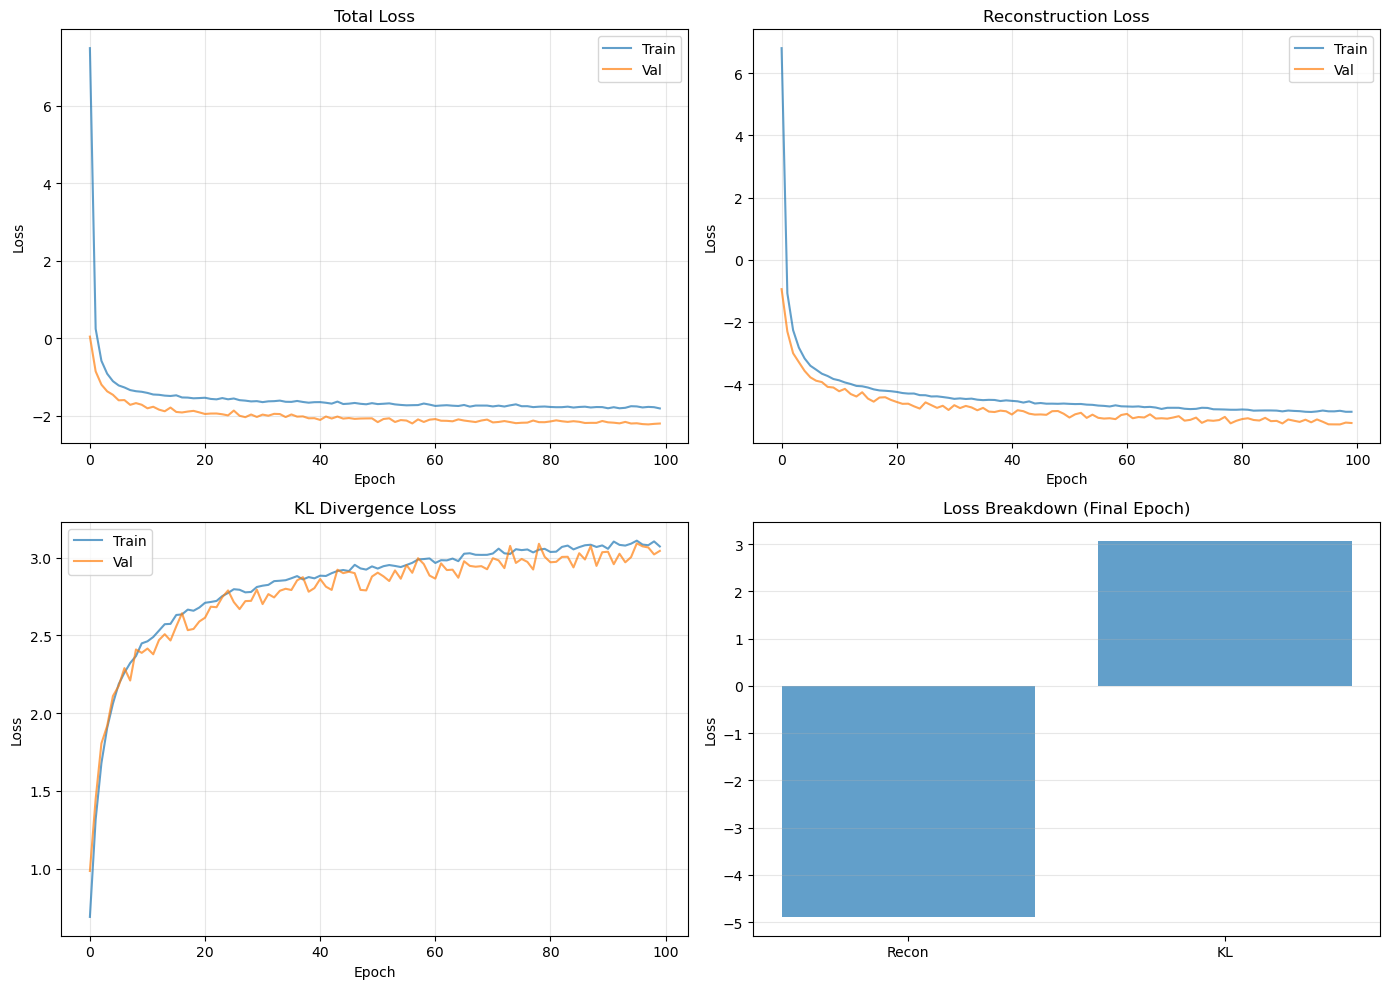


Final Training Loss: -1.8156
Final Validation Loss: -2.2059


In [26]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
axes[0, 0].plot(history['train_loss'], label='Train', alpha=0.7)
axes[0, 0].plot(history['val_loss'], label='Val', alpha=0.7)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction loss
axes[0, 1].plot(history['train_recon_loss'], label='Train', alpha=0.7)
axes[0, 1].plot(history['val_recon_loss'], label='Val', alpha=0.7)
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# KL loss
axes[1, 0].plot(history['train_kl_loss'], label='Train', alpha=0.7)
axes[1, 0].plot(history['val_kl_loss'], label='Val', alpha=0.7)
axes[1, 0].set_title('KL Divergence Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss breakdown (final epoch)
losses = ['Recon', 'KL']
values = [history['train_recon_loss'][-1], history['train_kl_loss'][-1]]
axes[1, 1].bar(losses, values, alpha=0.7)
axes[1, 1].set_title('Loss Breakdown (Final Epoch)')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nFinal Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")

## Inference and Reconstruction

In [27]:
def apply_continuous_activation(x_recon: np.ndarray, output_info: list) -> np.ndarray:
    """Apply the same tanh bound to continuous segments that compute_loss uses,
    so reconstruction/generation match what the model was actually trained against.
    Discrete (softmax/argmax) segments are left as raw logits -- argmax is
    invariant to monotonic transforms, so no activation is needed there.
    """
    x_recon = x_recon.copy()
    for start, dim, kind in output_info:
        if kind == 'continuous':
            end = start + dim
            x_recon[:, start:end] = np.tanh(x_recon[:, start:end])
    return x_recon

In [28]:
@torch.no_grad()
def encode_data(model: TVAE, data: np.ndarray, device: str) -> np.ndarray:
    """Encode data to latent space.
    
    Args:
        model: Trained TVAE model
        data: Input data (n_samples, input_dim)
        device: Device to use
        
    Returns:
        Latent representations (n_samples, latent_dim)
    """
    model.eval()
    data_tensor = torch.FloatTensor(data).to(device)
    mu, _ = model.encode(data_tensor)
    return mu.cpu().numpy()

@torch.no_grad()
def decode_latent(model: TVAE, latent: np.ndarray, device: str) -> np.ndarray:
    """Decode latent vectors to reconstructed data.
    
    Args:
        model: Trained TVAE model
        latent: Latent vectors (n_samples, latent_dim)
        device: Device to use
        
    Returns:
        Reconstructed data (n_samples, input_dim)
    """
    model.eval()
    latent_tensor = torch.FloatTensor(latent).to(device)
    recon = model.decode(latent_tensor)
    return recon.cpu().numpy()

@torch.no_grad()
def reconstruct(model: TVAE, data: np.ndarray, device: str, output_info: list) -> np.ndarray:
    """Reconstruct data through the VAE.
    
    Args:
        model: Trained TVAE model
        data: Input data (n_samples, input_dim)
        device: Device to use
        
    Returns:
        Reconstructed data (n_samples, input_dim)
    """
    latent = encode_data(model, data, device)
    recon = decode_latent(model, latent, device)
    recon = apply_continuous_activation(recon, output_info)
    return recon

In [29]:
# Encode all data to latent space
latent_vectors = encode_data(tvae, transformed, tvae_config.device if 'tvae_config' in dir() else 'cpu')
print(f"Latent vectors shape: {latent_vectors.shape}")
print(f"Latent vectors stats:")
print(f"  Mean: {latent_vectors.mean(axis=0)}")
print(f"  Std: {latent_vectors.std(axis=0)}")

Latent vectors shape: (20640, 4)
Latent vectors stats:
  Mean: [-0.01658974 -0.00357194 -0.00390614 -0.01037587]
  Std: [0.74505454 0.9152124  0.9158661  0.8308368 ]


In [30]:
# Reconstruct data
reconstructed_transformed = reconstruct(tvae, transformed, tvae_config.device if 'tvae_config' in dir() else 'cpu', preprocessor.get_output_info())

# Compare original and reconstructed
mse_recon = np.mean((transformed - reconstructed_transformed) ** 2)
print(f"\nVAE Reconstruction MSE: {mse_recon:.6f}")

# Inverse transform to original space
reconstructed_data = preprocessor.inverse_transform(reconstructed_transformed)
print(f"\nReconstructed data (first 5 rows):")
print(reconstructed_data.head())

# Compare with original data
print(f"\nOriginal data (first 5 rows):")
print(data.head())

# Calculate MAE for each column
print(f"\nReconstruction MAE per column:")
for col in data.columns:
    mae = np.abs(data[col].values - reconstructed_data[col].values).mean()
    print(f"  {col}: {mae:.6f}")


VAE Reconstruction MSE: 14.083361

Reconstructed data (first 5 rows):
     MedInc   HouseAge  AveRooms  AveBedrms  Population  AveOccup   Latitude  \
0  7.316566  48.315882  5.998660   1.027393  768.559766  2.617042  37.686582   
1  7.261973  26.463976  5.980745   1.025542  932.218715  2.819412  37.701565   
2  7.331911  48.368742  6.038451   1.027096  764.377202  2.639142  37.686392   
3  5.254070  48.524771  5.816180   1.027145  784.545788  2.465741  37.699907   
4  3.694733  48.705877  5.717672   1.029853  751.239248  2.368144  37.715234   

    Longitude  MedHouseVal  
0 -122.215604     3.659719  
1 -122.133407     3.676655  
2 -122.233123     3.656498  
3 -122.268049     3.674198  
4 -122.274667     3.687094  

Original data (first 5 rows):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      

## Generate Synthetic Data

In [31]:
@torch.no_grad()
def generate_synthetic_samples(model: TVAE, n_samples: int, 
                              device: str, output_info: list) -> np.ndarray:
    """Generate synthetic samples from the learned latent distribution.
    
    Args:
        model: Trained TVAE model
        n_samples: Number of samples to generate
        device: Device to use
        
    Returns:
        Synthetic data in preprocessed space (n_samples, input_dim)
    """
    model.eval()
    
    # Sample from standard normal distribution
    z = torch.randn(n_samples, model.config.latent_dim).to(device)
    
    # Decode
    synthetic = model.decode(z)
    synthetic = synthetic.cpu().numpy()
    synthetic = apply_continuous_activation(synthetic, output_info)
    return synthetic

# Generate synthetic samples
n_synthetic = 20000
synthetic_transformed = generate_synthetic_samples(tvae, n_synthetic, tvae_config.device if 'tvae_config' in dir() else 'cpu', preprocessor.get_output_info())

print(f"Synthetic data shape (preprocessed): {synthetic_transformed.shape}")

# Inverse transform to original space
synthetic_data = preprocessor.inverse_transform(synthetic_transformed)
print(f"\nSynthetic data (first 5 rows):")
print(synthetic_data.head())

print(f"\nSynthetic vs Original - Mean Comparison:")
for col in data.columns:
    orig_mean = data[col].mean()
    syn_mean = synthetic_data[col].mean()
    print(f"  {col}: Original={orig_mean:.4f}, Synthetic={syn_mean:.4f}")

Synthetic data shape (preprocessed): (20000, 54)

Synthetic data (first 5 rows):
     MedInc   HouseAge  AveRooms  AveBedrms   Population  AveOccup   Latitude  \
0  3.612194  16.900363  4.231691   1.058908  1802.049987  2.871815  33.994737   
1  7.115536  16.092267  7.970093   1.051677   912.861487  2.965172  37.063477   
2  3.630825  16.579193  5.902849   1.063554   856.761865  2.770174  37.360901   
3  2.028696  47.673463  3.911722   1.047282   682.932639  2.447040  33.978628   
4  3.568011  16.821863  5.793553   1.078300   768.154998  2.601796  38.265183   

    Longitude  MedHouseVal  
0 -118.119218     1.663830  
1 -122.036313     3.685005  
2 -120.926960     1.633681  
3 -117.289232     0.970959  
4 -121.961432     0.880555  

Synthetic vs Original - Mean Comparison:
  MedInc: Original=3.8707, Synthetic=3.7591
  HouseAge: Original=28.6395, Synthetic=28.6092
  AveRooms: Original=5.4290, Synthetic=5.3066
  AveBedrms: Original=1.0967, Synthetic=1.0692
  Population: Original=1425.476

In [32]:
synthetic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20000 non-null  float64
 1   HouseAge     20000 non-null  float64
 2   AveRooms     20000 non-null  float64
 3   AveBedrms    20000 non-null  float64
 4   Population   20000 non-null  float64
 5   AveOccup     20000 non-null  float64
 6   Latitude     20000 non-null  float64
 7   Longitude    20000 non-null  float64
 8   MedHouseVal  20000 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
from sdmetrics.reports.single_table import QualityReport, DiagnosticReport

In [ ]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=data)

print("Detected metadata:")
print(metadata.to_dict())

Detected metadata:
{'columns': {'MedInc': {'sdtype': 'numerical'}, 'HouseAge': {'sdtype': 'numerical'}, 'AveRooms': {'sdtype': 'numerical'}, 'AveBedrms': {'sdtype': 'numerical'}, 'Population': {'sdtype': 'numerical'}, 'AveOccup': {'sdtype': 'numerical'}, 'Latitude': {'pii': True, 'sdtype': 'latitude'}, 'Longitude': {'pii': True, 'sdtype': 'longitude'}, 'MedHouseVal': {'sdtype': 'numerical'}}, 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}


In [ ]:
report = QualityReport()
report.generate(real_data, synthetic_data, metadata.to_dict())

# print("Quality Report:")
# print(quality_report)

# # Get detailed scores
# print("\nDetailed Quality Scores:")
# print(quality_report.get_details(property_name='Column Shapes'))
# print("\n")
# print(quality_report.get_details(property_name='Column Pair Trends'))

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 152.43it/s]|
Column Shapes Score: 79.5%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 530.90it/s]|
Column Pair Trends Score: 93.87%

Overall Score (Average): 86.68%



In [37]:
report.get_score()

np.float64(0.8668414315017465)

In [38]:
report.get_properties()

,Property,Score
0,Column Shapes,0.795002
1,Column Pair Trends,0.938681


In [39]:
# Run diagnostic (checks for data validity issues)
diagnostioc_report = DiagnosticReport()
diagnostioc_report.generate(
    real_data,
    synthetic_data,
    metadata.to_dict()
)

diagnostioc_report.get_properties()

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 9/9 [00:00<00:00, 546.45it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 299.21it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



,Property,Score
0,Data Validity,1.0
1,Data Structure,1.0


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

X_real = data.drop(columns=['MedHouseVal'])
y_real = data['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

X_syn = synthetic_data.drop(columns=['MedHouseVal'])
y_syn = synthetic_data['MedHouseVal']

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'Lasso': Lasso(random_state=42)
}

results = []
for name, model_cls in models.items():
    m_real = model_cls.__class__(**model_cls.get_params())
    m_real.fit(X_train, y_train)
    r2_real = r2_score(y_test, m_real.predict(X_test))

    m_syn = model_cls.__class__(**model_cls.get_params())
    m_syn.fit(X_syn, y_syn)
    r2_syn = r2_score(y_test, m_syn.predict(X_test))

    results.append({
        'model': name,
        'r2_real': r2_real,
        'r2_synthetic': r2_syn,
        'utility_ratio': r2_syn / r2_real
    })

utility_df = pd.DataFrame(results)
print(utility_df)
print(f"\nMean utility ratio across models: {utility_df['utility_ratio'].mean():.4f}")

              model   r2_real  r2_synthetic  utility_ratio
0      RandomForest  0.804850      0.549794       0.683101
1  GradientBoosting  0.775645      0.549414       0.708332
2             Lasso  0.284167      0.203525       0.716215

Mean utility ratio across models: 0.7025
